# Demo of DISC tomography based on a simple model to show ray tracing 

## Description
This notebook implements DISC based ray tracing using a given velocity model.  


## Date
2026-07

In [1]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os

In [2]:
#####Step2 loading real model

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

vel1=address+'/data/vel1.npy'

v_true=np.load(vel1)[::2,::2]  ###load true velocity model and downsample by 2


nx, ny = 50, 50  ###model size 
dx = dy =0.1       ###spacing rinterval


v_low = 2000     ###low velocity
v_high = 4500    ###high velocity

#########geometry setting
n_sources = 1
sources = [(0, 0.5) for i in range(n_sources)] #### source locations (x,y)
n_receivers = 1
receivers = [((nx-1)*dx, 4.5) for i in range(n_receivers)]  ### receiver locations (x,y)

In [3]:
#####Step3 build ray path matrix based on eikonal wave equation

sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers


from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation

ifwav=True
traveltimes,ray_paths,timewav=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny, ifwav=ifwav)  ###compute traveltime and ray paths   


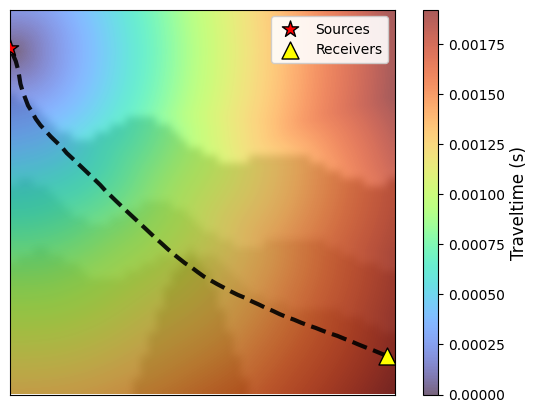

In [ ]:
# ########Step 4 display the traveltime field and ray paths

figadd=address+'/Figure/'

fig, ax = plt.subplots(figsize=(6,5))

# ---- Structure (strong grayscale) ----
im1 = ax.imshow(v_true,
                cmap='gray_r',         # reverse gray → dark structure
                alpha=0.8,             # <--- stronger visibility
                interpolation='bicubic',
                extent=[0,nx*dx,ny*dy,0],
                zorder=1)

# ---- Traveltime field ----
im2 = ax.imshow(timewav,
                cmap='turbo',
                alpha=0.65,            # reduced so structure shows
                interpolation='bilinear',
                extent=[0,nx*dx,ny*dy,0],
                zorder=2)

# Colorbar
cax = fig.add_axes([0.88, 0.11, 0.025, 0.77])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("Traveltime (s)", fontsize=12)

# Rays
for ray_x, ray_y in ray_paths:
    ax.plot(ray_x, ray_y, 'k--', linewidth=3, alpha=0.9, zorder=5)

# Markers
ax.scatter(sources_x, sources_y, s=150, c="red", marker="*", edgecolor='black', zorder=6, label="Sources")
ax.scatter(receivers_x, receivers_y, s=150, c="yellow", marker="^", edgecolor='black', zorder=6, label="Receivers")

ax.legend(framealpha=0.9, facecolor="white")
ax.set_xticks([]); ax.set_yticks([])
# plt.savefig(figadd + 'sketch.png', dpi=300, bbox_inches='tight')

plt.show()
